# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

**Phạm Văn Hoàng Anh Tú — MSSV 2A202602507** · repo: `tubepvhat1604-bot/K4-DAY02-PhamVanHoangAnhTu-2A202602507`

Notebook chạy trên Google Colab, GPU T4. Code nằm trong `code/*.py`; notebook chỉ gọi hàm.
Checkpoint và log của mọi lần chạy lưu ở Drive `/content/drive/MyDrive/deepweeds_runs/<exp_id>/seed<k>/` (ngoài repo, có resume).
Ảnh giải nén vào đĩa cục bộ `/content/data` (không giải nén vào Drive).

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [18]:
# Ô 0.1 — mount Drive, đặt đường dẫn, import (chạy đầu tiên ở MỌI phiên)
from google.colab import drive
drive.mount('/content/drive')

import os, sys, importlib, platform
REPO_DIR = "/content/drive/MyDrive/K4-DAY02-PhamVanHoangAnhTu-2A202602507"
SUB_DIR  = f"{REPO_DIR}/submissions/2A202602507_pham_van_hoang_anh_tu"
CODE_DIR = f"{SUB_DIR}/code"
RUNS_DIR = "/content/drive/MyDrive/deepweeds_runs"     # checkpoint + log, NGOÀI repo
FIG_DIR  = f"{SUB_DIR}/figures"                         # ảnh EDA/kiểm tra cho báo cáo
os.chdir(SUB_DIR)
for p in (REPO_DIR, CODE_DIR):        # REPO_DIR để import eval.py, CODE_DIR để import code của mình
    if p not in sys.path:
        sys.path.insert(0, p)
os.makedirs(RUNS_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)

!pip -q install timm openpyxl

import numpy as np, pandas as pd, torch, torchvision, timm
print("python", platform.python_version(), "| torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| timm", timm.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")
print("cwd:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
python 3.13.15 | torch 2.11.0+cpu | torchvision 0.26.0+cpu | timm 1.0.29 | numpy 2.1.3 | pandas 2.2.3
GPU: KHÔNG CÓ GPU
cwd: /content/drive/MyDrive/K4-DAY02-PhamVanHoangAnhTu-2A202602507/submissions/2A202602507_pham_van_hoang_anh_tu


In [32]:
# Ô 0.1b — tải code mới nhất (và report.md, README.md) từ nhánh Claude đã chạy thử, đè vào thư mục bài nộp
import urllib.request
URL_SUB = ("https://raw.githubusercontent.com/tubepvhat1604-bot/K4-DAY02-PhamVanHoangAnhTu-2A202602507/"
           "claude/project-thread-mdpq02/submissions/2A202602507_pham_van_hoang_anh_tu/")
for name in ["train.py", "inference.py", "benchmark.py", "buoc3.py", "buoc4.py", "buoc5.py", "test_code.py",
             "kaggle_buoc2.ipynb", "kaggle_buoc2b.ipynb", "kaggle_buoc3.ipynb", "kaggle_buoc4.ipynb"]:
    urllib.request.urlretrieve(URL_SUB + "code/" + name, f"{CODE_DIR}/{name}")
for name in ["report.md", "README.md"]:
    urllib.request.urlretrieve(URL_SUB + name, f"{SUB_DIR}/{name}")
print("Đã cập nhật:", sorted(os.listdir(CODE_DIR)), "+ report.md, README.md")

Đã cập nhật: ['__pycache__', 'benchmark.py', 'buoc3.py', 'buoc4.py', 'buoc5.py', 'dataset.py', 'inference.py', 'kaggle_buoc2.ipynb', 'kaggle_buoc2b.ipynb', 'kaggle_buoc3.ipynb', 'kaggle_buoc4.ipynb', 'lab_day2.ipynb', 'losses.py', 'model.py', 'pipeline_checks.py', 'test_code.py', 'train.py'] + report.md, README.md


In [20]:
# Ô 0.2 — nạp (lại) code từ các file .py. Sửa file .py xong thì chạy lại ô này, KHÔNG cần khởi động lại phiên.
# (Không dùng %load_ext autoreload: lỗi với Python 3.13 trên Colab.)
import dataset, model, losses, train, pipeline_checks, eval as ev
for m in (dataset, model, losses, train, pipeline_checks, ev):
    importlib.reload(m)
from train import Config, run
print("Đã nạp:", [m.__name__ for m in (dataset, model, losses, train, pipeline_checks, ev)])

Đã nạp: ['dataset', 'model', 'losses', 'train', 'pipeline_checks', 'eval']


### Tải dữ liệu vào đĩa cục bộ `/content/data`
Mỗi phiên Colab chạy lại ô này. Lần đầu tải `images.zip` từ Zenodo (~490 MB) rồi **lưu một bản zip** vào
`MyDrive/deepweeds_data/` (chỉ file zip, ngoài repo) để các phiên sau chép từ Drive cho nhanh. Ảnh luôn giải nén ra `/content/data`.
4 file CSV fold 0 tải nguyên bản từ GitHub của tác giả, không sửa.

In [21]:
# Ô 0.3 — tải ảnh + CSV, kiểm tra MD5, giải nén (chạy lại mỗi phiên; đã có thì bỏ qua)
import hashlib, shutil, zipfile, urllib.request

DATA_DIR   = "/content/data"
LABELS_DIR = f"{DATA_DIR}/labels"
ZIP_LOCAL  = f"{DATA_DIR}/images.zip"
ZIP_DRIVE  = "/content/drive/MyDrive/deepweeds_data/images.zip"
ZIP_URL    = "https://zenodo.org/records/7939060/files/images.zip?download=1"
ZIP_MD5    = "b7b30f96d466fba86016aa5a26606e0f"
SAVE_ZIP_TO_DRIVE = True
os.makedirs(LABELS_DIR, exist_ok=True)

def md5sum(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def download(url, path):
    with urllib.request.urlopen(url) as r, open(path + ".part", "wb") as f:
        total, done = int(r.headers.get("Content-Length", 0)), 0
        while chunk := r.read(1 << 22):
            f.write(chunk); done += len(chunk)
            if done % (100 << 20) < (1 << 22):
                print(f"  {done >> 20} / {total >> 20} MB", flush=True)
    os.replace(path + ".part", path)

if not os.path.exists(f"{DATA_DIR}/.images_ok"):
    if not os.path.exists(ZIP_LOCAL):
        if os.path.exists(ZIP_DRIVE):
            print("Chép images.zip từ Drive..."); shutil.copy(ZIP_DRIVE, ZIP_LOCAL)
        else:
            print("Tải images.zip từ Zenodo..."); download(ZIP_URL, ZIP_LOCAL)
    got = md5sum(ZIP_LOCAL)
    assert got == ZIP_MD5, f"MD5 sai: {got}. Xoá {ZIP_LOCAL} (và {ZIP_DRIVE} nếu có) rồi chạy lại ô này."
    print("MD5 đúng:", got)
    if SAVE_ZIP_TO_DRIVE and not os.path.exists(ZIP_DRIVE):
        os.makedirs(os.path.dirname(ZIP_DRIVE), exist_ok=True); shutil.copy(ZIP_LOCAL, ZIP_DRIVE)
        print("Đã lưu bản zip vào", ZIP_DRIVE)
    with zipfile.ZipFile(ZIP_LOCAL) as z:
        z.extractall(f"{DATA_DIR}/images")
    open(f"{DATA_DIR}/.images_ok", "w").close()

BASE_URL = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    if not os.path.exists(f"{LABELS_DIR}/{name}.csv"):
        urllib.request.urlretrieve(f"{BASE_URL}/{name}.csv", f"{LABELS_DIR}/{name}.csv")

# Tìm thư mục thật sự chứa ảnh .jpg (zip có thể có thư mục con)
IMAGES_DIR = max((r for r, _, fs in os.walk(f"{DATA_DIR}/images")), key=lambda r: len(os.listdir(r)))
print("IMAGES_DIR =", IMAGES_DIR, "|", sum(f.endswith(".jpg") for f in os.listdir(IMAGES_DIR)), "ảnh .jpg")
print("CSV:", sorted(os.listdir(LABELS_DIR)))

IMAGES_DIR = /content/data/images | 17509 ảnh .jpg
CSV: ['labels.csv', 'test_subset0.csv', 'train_subset0.csv', 'val_subset0.csv']


In [22]:
# Ô 0.4 — cấu hình dùng chung cho MỌI thí nghiệm (đặt ở đây để Restart & Run All chạy được từ trên xuống)
BASE = dict(images_dir=IMAGES_DIR, labels_dir=LABELS_DIR, out_dir=RUNS_DIR,
            curves_dir=f"{SUB_DIR}/curves", pred_dir=f"{SUB_DIR}/predictions", num_workers=2)
print(Config(**BASE))

Config(exp_id='T00', seed=0, fold=0, desc='', backbone='resnet50', init='finetune', pretrained=True, drop_rate=0.0, img_size=224, aug='basic', sampler=None, mix=None, mix_alpha=1.0, cache_images=True, loss='ce', label_smoothing=0.0, focal_gamma=2.0, class_weight_beta=None, epochs=12, batch_size=64, lr_backbone=0.0001, lr_head=0.001, weight_decay=0.05, warmup_epochs=1.0, ema_decay=None, grad_clip=None, amp=True, num_workers=2, max_steps_per_epoch=None, images_dir='/content/data/images', labels_dir='/content/data/labels', out_dir='/content/drive/MyDrive/deepweeds_runs', pred_dir='/content/drive/MyDrive/K4-DAY02-PhamVanHoangAnhTu-2A202602507/submissions/2A202602507_pham_van_hoang_anh_tu/predictions', curves_dir='/content/drive/MyDrive/K4-DAY02-PhamVanHoangAnhTu-2A202602507/submissions/2A202602507_pham_van_hoang_anh_tu/curves', logs_dir='logs', expected_total=17509, save_test_predictions=False, export_val_predictions=False)


## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

In [ ]:
# Ô B0.1 — kiểm tra chia dữ liệu bắt buộc (S1-S4): số ảnh mỗi tập/lớp, giao rỗng, hợp = 17.509, mọi file tồn tại
train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
split_info = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)

Số ảnh mỗi tập: train 10501 (59.97%), val 3501 (20.00%), test 3507 (20.03%)

Số ảnh mỗi lớp trong từng tập:
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106

Giao từng cặp (theo Filename): {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Hợp ba tập: 17509 ảnh (kỳ vọng 17509)
File trong CSV nhưng không có trong thư mục ảnh: 0

KIỂM TRA CHIA DỮ LIỆU: ĐẠT


In [ ]:
# Ô B0.2 — EDA: phân bố lớp (biểu đồ), đối chiếu Table 1, ảnh mẫu 3 ảnh/lớp, thống kê kích thước ảnh
eda_counts = pipeline_checks.eda(train_df, val_df, test_df, IMAGES_DIR, FIG_DIR, labels_csv=f"{LABELS_DIR}/labels.csv")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Ô B0.3 — test tự viết (focal γ=0 ≡ CE, label smoothing, CutMix lam theo diện tích thật, nhóm tham số, EMA...)
#          và test của repo (eval.py + khung starter/)
!cd {CODE_DIR} && python -m unittest test_code 2>&1 | tail -n 3
!cd {REPO_DIR} && python -m unittest discover -s tests 2>&1 | tail -n 3

Ran 13 tests in 3.757s

OK
Ran 38 tests in 6.310s

OK


In [ ]:
# Ô B0.4 — kiểm tra pipeline (slide trang 59, GUIDE mục 1.3)
train.set_seed(0)                                                   # 1) cố định seed
val_loader = dataset.make_loader(val_df, IMAGES_DIR, dataset.build_transforms(False, 224), 64, train=False)
pipeline_checks.initial_loss("resnet50", val_loader)                # 2) loss ban đầu ≈ ln 9 = 2,197
losses_ob = pipeline_checks.overfit_one_batch("resnet50", train_df, IMAGES_DIR, n=16, steps=60)  # 3) overfit 1 batch

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Loss ban đầu (resnet50) = 2.1756; kỳ vọng ln(9) = 2.1972; lệch 0.0216
  bước   0: loss 2.1815
  bước  10: loss 0.2005
  bước  20: loss 0.0047
  bước  30: loss 0.0007
  bước  40: loss 0.0003
  bước  50: loss 0.0002
  bước  59: loss 0.0002
Overfit 16 ảnh: loss 2.182 -> 0.0002; accuracy trên batch (eval) 1.00


In [ ]:
# Ô B0.5 — xem ảnh sau augmentation (đã giải chuẩn hoá) cùng nhãn, và ảnh sau CutMix
for aug in ("basic", "trivial"):
    pipeline_checks.show_augmented(train_df, IMAGES_DIR, aug, f"{FIG_DIR}/aug_{aug}.png", n=8)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Ô B0.6 — ước lượng thời gian 1 epoch mỗi backbone (30 bước train AMP + suy luận val), để lập ngân sách GPU
BACKBONES = ["resnet50", "convnext_tiny", "deit_small_patch16_224", "efficientnet_b0",
             "mobilenetv3_large_100", "swin_tiny_patch4_window7_224"]
if os.path.exists(f"{FIG_DIR}/timing_estimate.csv"):        # đã đo ở phiên GPU trước: chỉ đọc lại
    timing = pd.read_csv(f"{FIG_DIR}/timing_estimate.csv")
else:
    timing = pipeline_checks.time_backbones(BACKBONES, train_df, IMAGES_DIR)
    timing.to_csv(f"{FIG_DIR}/timing_estimate.csv", index=False)
timing

  đã nạp 2000/10501 ảnh vào RAM
  đã nạp 4000/10501 ảnh vào RAM
  đã nạp 6000/10501 ảnh vào RAM
  đã nạp 8000/10501 ảnh vào RAM
  đã nạp 10000/10501 ảnh vào RAM
Cache RAM: 10501 ảnh
{'backbone': 'resnet50', 's_per_step': 0.23, 'img_per_s': 279, 'epoch_min_est': 0.69, 'run_12ep_min_est': 8.3}


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

{'backbone': 'convnext_tiny', 's_per_step': 0.268, 'img_per_s': 239, 'epoch_min_est': 0.81, 'run_12ep_min_est': 9.8}


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

...

{'backbone': 'mobilenetv3_large_100', 's_per_step': 0.225, 'img_per_s': 285, 'epoch_min_est': 0.64, 'run_12ep_min_est': 7.6}


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

{'backbone': 'swin_tiny_patch4_window7_224', 's_per_step': 0.349, 'img_per_s': 183, 'epoch_min_est': 1.07, 'run_12ep_min_est': 12.9}


,backbone,s_per_step,img_per_s,epoch_min_est,run_12ep_min_est
0,resnet50,0.230,279,0.69,8.3
1,convnext_tiny,0.268,239,0.81,9.8
2,deit_small_patch16_224,0.179,357,0.54,6.4
3,efficientnet_b0,0.183,349,0.55,6.6
4,mobilenetv3_large_100,0.225,285,0.64,7.6
5,swin_tiny_patch4_window7_224,0.349,183,1.07,12.9


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [ ]:
# Ô B1.1 — Bước 1: 6 backbone, công thức nền T00, seed 0. Chạy lại được: run xong thì bỏ qua, run dở thì resume.
BACKBONE_RUNS = [
    ("B01", "resnet50", "resnet50"),
    ("B02", "convnext_tiny", "convnext_tiny"),
    ("B03", "deit_small_patch16_224", "deit_small"),
    ("B04", "efficientnet_b0", "efficientnet_b0"),
    ("B05", "mobilenetv3_large_100", "mobilenetv3"),
    ("B06", "swin_tiny_patch4_window7_224", "swin_tiny"),
]
for exp_id, bb, desc in BACKBONE_RUNS:
    run(Config(exp_id=exp_id, backbone=bb, desc=desc, seed=0, **BASE))

Cache RAM: 10501 ảnh
  đã nạp 2000/3501 ảnh vào RAM
Cache RAM: 14002 ảnh
[B01 seed0] ep  1/12 | train loss 1.6573 | val loss 1.2489 | val macro-F1 0.2075 | top-1 0.5587 | 47s train | *best*
[B01 seed0] ep  2/12 | train loss 0.9812 | val loss 0.7693 | val macro-F1 0.6068 | top-1 0.7301 | 45s train | *best*
[B01 seed0] ep  3/12 | train loss 0.7030 | val loss 0.6261 | val macro-F1 0.7035 | top-1 0.7841 | 46s train | *best*
[B01 seed0] ep  4/12 | train loss 0.5732 | val loss 0.5185 | val macro-F1 0.7583 | top-1 0.8215 | 47s train | *best*
[B01 seed0] ep  5/12 | train loss 0.4976 | val loss 0.5251 | val macro-F1 0.7443 | top-1 0.8163 | 47s train
[B01 seed0] ep  6/12 | train loss 0.4527 | val loss 0.4502 | val macro-F1 0.7940 | top-1 0.8475 | 46s train | *best*
[B01 seed0] ep  7/12 | train loss 0.4277 | val loss 0.4292 | val macro-F1 0.7991 | top-1 0.8535 | 48s train | *best*
[B01 seed0] ep  8/12 | train loss 0.3910 | val loss 0.4268 | val macro-F1 0.7967 | top-1 0.8532 | 47s train
[B01 seed

/content/drive/MyDrive/K4-DAY02-PhamVanHoangAnhTu-2A202602507/submissions/2A202602507_pham_van_hoang_anh_tu/code/train.py:210: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[B02 seed0] ep  1/12 | train loss 0.7644 | val loss 0.4076 | val macro-F1 0.8049 | top-1 0.8618 | 55s train | *best*
[B02 seed0] ep  2/12 | train loss 0.3272 | val loss 0.2773 | val macro-F1 0.8698 | top-1 0.9029 | 54s train | *best*
[B02 seed0] ep  3/12 | train loss 0.2183 | val loss 0.2214 | val macro-F1 0.9117 | top-1 0.9257 | 54s train | *best*
[B02 seed0] ep  4/12 | train loss 0.1772 | val loss 0.2293 | val macro-F1 0.9124 | top-1 0.9306 | 53s train | *best*
[B02 seed0] ep  5/12 | train loss 0.1452 | val loss 0.1310 | val macro-F1 0.9509 | top-1 0.9623 | 53s train | *best*
[B02 seed0] ep  6/12 | train loss 0.1077 | val loss 0.1417 | val macro-F1 0.9446 | top-1 0.9557 | 54s train
[B02 seed0] ep  7/12 | train loss 0.0934 | val loss 0.1099 | val macro-F1 0.9581 | top-1 0.9663 | 53s train | *best*
[B02 seed0] ep  8/12 | train loss 0.0709 | val loss 0.1148 | val macro-F1 0.9573 | top-1 0.9666 | 53s train
[B02 seed0] ep  9/12 | train loss 0.0496 | val loss 0.1150 | val macro-F1 0.9616 |

/content/drive/MyDrive/K4-DAY02-PhamVanHoangAnhTu-2A202602507/submissions/2A202602507_pham_van_hoang_anh_tu/code/train.py:210: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[B03 seed0] ep  1/12 | train loss 0.9193 | val loss 0.3715 | val macro-F1 0.8375 | top-1 0.8780 | 41s train | *best*
[B03 seed0] ep  2/12 | train loss 0.3650 | val loss 0.2510 | val macro-F1 0.8801 | top-1 0.9160 | 37s train | *best*
[B03 seed0] ep  3/12 | train loss 0.2410 | val loss 0.2878 | val macro-F1 0.8799 | top-1 0.9015 | 41s train
[B03 seed0] ep  4/12 | train loss 0.2101 | val loss 0.2204 | val macro-F1 0.8998 | top-1 0.9266 | 40s train | *best*
[B03 seed0] ep  5/12 | train loss 0.1557 | val loss 0.1700 | val macro-F1 0.9280 | top-1 0.9480 | 42s train | *best*
[B03 seed0] ep  6/12 | train loss 0.1301 | val loss 0.1748 | val macro-F1 0.9253 | top-1 0.9420 | 42s train
[B03 seed0] ep  7/12 | train loss 0.1144 | val loss 0.1395 | val macro-F1 0.9392 | top-1 0.9540 | 40s train | *best*
[B03 seed0] ep  8/12 | train loss 0.0864 | val loss 0.1301 | val macro-F1 0.9410 | top-1 0.9592 | 41s train | *best*
[B03 seed0] ep  9/12 | train loss 0.0684 | val loss 0.1336 | val macro-F1 0.9374 |

/content/drive/MyDrive/K4-DAY02-PhamVanHoangAnhTu-2A202602507/submissions/2A202602507_pham_van_hoang_anh_tu/code/train.py:210: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[B04 seed0] ep  1/12 | train loss 2.1469 | val loss 1.4309 | val macro-F1 0.4102 | top-1 0.5501 | 40s train | *best*
[B04 seed0] ep  2/12 | train loss 0.8305 | val loss 1.0668 | val macro-F1 0.5265 | top-1 0.6558 | 35s train | *best*
[B04 seed0] ep  3/12 | train loss 0.5675 | val loss 0.8761 | val macro-F1 0.6219 | top-1 0.7209 | 35s train | *best*
[B04 seed0] ep  4/12 | train loss 0.4403 | val loss 0.7659 | val macro-F1 0.6597 | top-1 0.7452 | 36s train | *best*
[B04 seed0] ep  5/12 | train loss 0.3683 | val loss 0.7336 | val macro-F1 0.6643 | top-1 0.7584 | 35s train | *best*
[B04 seed0] ep  6/12 | train loss 0.3220 | val loss 0.6128 | val macro-F1 0.7211 | top-1 0.7955 | 36s train | *best*
[B04 seed0] ep  7/12 | train loss 0.2856 | val loss 0.5600 | val macro-F1 0.7519 | top-1 0.8143 | 36s train | *best*
[B04 seed0] ep  8/12 | train loss 0.2535 | val loss 0.5534 | val macro-F1 0.7627 | top-1 0.8201 | 37s train | *best*
[B04 seed0] ep  9/12 | train loss 0.2331 | val loss 0.5352 | val

In [ ]:
# Ô B1.2 — bảng Backbones từ log
bb_df = train.collect_summaries(RUNS_DIR, "B")
cols = ["exp_id", "backbone", "weight_tag", "params_M", "gmacs", "img_size", "epochs", "seed", "best_epoch",
        "val_macro_f1", "val_top1", "val_balanced_acc", "train_time_per_epoch_s", "latency_b1_ms_prelim"]
bb_df[cols].to_csv(f"{SUB_DIR}/logs/backbones_summary.csv", index=False)
bb_df[cols].sort_values("val_macro_f1", ascending=False)

,exp_id,backbone,weight_tag,params_M,gmacs,img_size,epochs,seed,best_epoch,val_macro_f1,val_top1,val_balanced_acc,train_time_per_epoch_s,latency_b1_ms_prelim
1,B02,convnext_tiny,convnext_tiny.in12k_ft_in1k,27.827,4.455,224,12,0,12,0.966636,0.974007,0.965194,53.276424,8.080396
5,B06,swin_tiny_patch4_window7_224,swin_tiny_patch4_window7_224.ms_in1k,27.526,4.490,224,12,0,7,0.948524,0.960011,0.946533,68.637200,18.207182
2,B03,deit_small_patch16_224,deit_small_patch16_224.fb_in1k,21.669,4.599,224,12,0,11,0.947028,0.963439,0.945097,40.480248,6.592135
0,B01,resnet50,resnet50.a1_in1k,23.526,4.087,224,12,0,12,0.814508,0.865467,0.789864,46.884855,7.452153
3,B04,efficientnet_b0,efficientnet_b0.ra_in1k,4.019,0.385,224,12,0,12,0.775795,0.834333,0.771649,36.029686,10.807676
4,B05,mobilenetv3_large_100,mobilenetv3_large_100.ra_in1k,4.214,0.215,224,12,0,12,0.724458,0.798343,0.689549,31.812576,8.520377


### Kết quả Bước 1 (val, fold 0, seed 0, công thức nền T00, 12 epoch)

| exp_id | backbone (tag timm) | Params (M) | GMAC | best epoch | macro-F1 val | top-1 val | train/epoch (s) | độ trễ b=1 sơ bộ (ms) |
|---|---|---|---|---|---|---|---|---|
| B02 | convnext_tiny.in12k_ft_in1k | 27,8 | 4,46 | 12 | **0,9666** | 0,9740 | 53,3 | 8,1 |
| B06 | swin_tiny_patch4_window7_224.ms_in1k | 27,5 | 4,49 | 7 | 0,9485 | 0,9600 | 68,6 | 18,2 |
| B03 | deit_small_patch16_224.fb_in1k | 21,7 | 4,60 | 11 | 0,9470 | 0,9634 | 40,5 | 6,6 |
| B01 | resnet50.a1_in1k | 23,5 | 4,09 | 12 | 0,8145 | 0,8655 | 46,9 | 7,5 |
| B04 | efficientnet_b0.ra_in1k | 4,0 | 0,39 | 12 | 0,7758 | 0,8343 | 36,0 | 10,8 |
| B05 | mobilenetv3_large_100.ra_in1k | 4,2 | 0,22 | 12 | 0,7245 | 0,7983 | 31,8 | 8,5 |

Nguồn: `logs/backbones_summary.csv`. Biểu đồ: `curves/B01_resnet50.png` … `curves/B06_swin_tiny.png`. Mới có 1 seed.

**So với dự đoán**
- Đúng: ConvNeXt-T đứng đầu.
- Đúng một nửa: Swin-T đứng thứ hai, nhưng chỉ hơn DeiT-S 0,0015. Mới 1 seed thì hai mạng này **không phân biệt được**.
- Sai: ResNet-50 thấp hơn ConvNeXt-T 15,2 điểm macro-F1, không phải khoảng 1 điểm như dự đoán. EfficientNet-B0 và MobileNetV3 thấp hơn 19–24 điểm, không phải 1–3 điểm.

**Đo được và phỏng đoán**
- *Đo được:* ba mạng CNN dùng BatchNorm (B01, B04, B05) đều đạt best epoch = 12, tức là đến epoch cuối vẫn còn tăng. Hai mạng transformer đạt đỉnh sớm hơn (DeiT ở epoch 11, Swin ở epoch 7).
- *Phỏng đoán, chưa kiểm chứng:* ba mạng này đang thiếu khớp (underfit) với công thức nền. LR backbone 1e-4 trong 12 epoch có thể quá nhỏ cho các CNN dùng BatchNorm. Bộ trọng số `resnet50.a1` được huấn luyện bằng BCE + LAMB với augmentation mạnh, nên có thể khó tinh chỉnh ở LR thấp. ConvNeXt-T có lợi thế được tiền huấn luyện trên ImageNet-22k (`in12k`). Muốn kiểm chứng thì cần chạy thêm, ví dụ tăng LR cho ResNet-50. Bài này không chạy thí nghiệm đó vì ngân sách GPU có hạn.
- *FLOPs không dự đoán được độ trễ:* EfficientNet-B0 có số GMAC chỉ bằng khoảng 1/10 ResNet-50 (0,39 so với 4,09) nhưng độ trễ batch 1 lại cao hơn (10,8 ms so với 7,5 ms). Swin-T có GMAC gần bằng ConvNeXt-T nhưng chậm hơn khoảng 2,3 lần (18,2 ms so với 8,1 ms). Đây mới là một lần đo sơ bộ; Bước 3 sẽ đo kỹ p50/p95/p99.
- *Thời gian train không tỉ lệ với GMAC:* MobileNetV3 có GMAC bằng khoảng 1/19 ResNet-50 nhưng chỉ train nhanh hơn khoảng 1,5 lần (31,8 s so với 46,9 s mỗi epoch). Phỏng đoán: việc train bị nghẽn ở khâu CPU đọc và augmentation ảnh (Colab có 2 nhân CPU), không phải ở GPU.

**Chọn backbone đi tiếp: B02 ConvNeXt-T**
- Có macro-F1 val cao nhất: 0,9666, hơn mạng đứng sau (Swin-T) 1,8 điểm.
- Độ trễ sơ bộ 8,1 ms, nhanh hơn Swin-T khoảng 2,3 lần và chỉ chậm hơn DeiT-S 1,5 ms.
- Chỉ đi tiếp với **một** backbone để vừa ngân sách GPU của Colab miễn phí.
- Chênh lệch 1,8 điểm mới đo trên 1 seed. Ở đầu Bước 2 sẽ chạy thêm T00 seed 1 và 2 để ước lượng nhiễu giữa các seed.


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

### Dự đoán trước khi chạy Bước 2 (ConvNeXt-T, 12 epoch, seed 0; so với T00)
- Nhiễu seed của T00 dự kiến khoảng 0,3–0,5 điểm macro-F1, nên nhiều thay đổi nhỏ sẽ "không phân biệt được".
- T01 đóng băng backbone: thấp hơn T00 rõ rệt (5–15 điểm) vì đặc trưng ImageNet không khớp hoàn toàn ảnh cỏ dại.
- T02 train từ đầu: thấp nhất, thấp hơn T00 ít nhất 30 điểm vì 10k ảnh và 12 epoch không đủ.
- T03 TrivialAugment, T04 CutMix: ngang hoặc giảm nhẹ, vì chính quy hoá mạnh thường cần nhiều epoch hơn 12.
- T05 lật dọc + xoay 90°: tăng nhẹ vì ảnh chụp từ trên xuống nên xoay vẫn là ảnh hợp lệ.
- T06 label smoothing, T07 focal: macro-F1 ngang T00; ECE thay đổi.
- T08 CE trọng số class-balanced, T09 sampler cân bằng: F1 Negatives giảm nhẹ, F1 lớp hiếm tăng nhẹ, macro-F1 gần ngang.
- T10 EMA: ngang hoặc tăng nhẹ.
- (Bước 2 chạy trên Kaggle T4 bằng code/kaggle_buoc2.ipynb vì Colab miễn phí hết lượt GPU.)

In [23]:
# Ô B2.M — các bước chạy GPU nằm trên Kaggle (code/kaggle_buoc*.ipynb) vì Colab miễn phí hết lượt GPU.
#          Gộp MỌI file kaggle_buoc*.zip đã đưa lên Drive vào RUNS_DIR và thư mục bài nộp. Chạy lại được.
import glob, zipfile
for zp in sorted(glob.glob("/content/drive/MyDrive/deepweeds_data/kaggle_buoc*.zip")):
    n_done = n_files = 0
    with zipfile.ZipFile(zp) as z:
        for name in z.namelist():
            if name.endswith("/"):
                continue
            top, rest = name.split("/", 1)
            dst = os.path.join(RUNS_DIR if top == "deepweeds_runs" else SUB_DIR, rest)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            with z.open(name) as fsrc, open(dst, "wb") as fdst:
                fdst.write(fsrc.read())
            n_files += 1
            n_done += top == "deepweeds_runs" and name.endswith("done.json")
    print(f"{os.path.basename(zp)}: gộp {n_files} file, {n_done} run")

kaggle_buoc2.zip: gộp 118 file, 13 run
kaggle_buoc2b.zip: gộp 38 file, 4 run
kaggle_buoc3.zip: gộp 5 file, 0 run
kaggle_buoc4.zip: gộp 33 file, 0 run


In [ ]:
# Ô B2.1 — Bước 2: mốc T00 (3 seed) + T01–T10 (mỗi cái chỉ khác T00 đúng một yếu tố, seed 0). GIỐNG Ô K5 trên Kaggle.
#          Các run đã có done.json (gộp từ Kaggle) sẽ được bỏ qua, nên Restart & Run All không train lại.
T_BASE = dict(BASE, backbone="convnext_tiny")   # ConvNeXt-T, chọn ở Bước 1
RUNS = [
    ("T00", 0, "base",        {}),
    ("T00", 1, "base",        {}),
    ("T00", 2, "base",        {}),
    ("T01", 0, "frozen",      dict(init="frozen")),                                # A: đóng băng backbone, chỉ train head
    ("T02", 0, "scratch",     dict(init="scratch")),                               # A: từ đầu, không pretrained
    ("T03", 0, "trivial",     dict(aug="trivial")),                                # B: + TrivialAugmentWide
    ("T04", 0, "cutmix",      dict(mix="cutmix")),                                 # B: + CutMix (alpha 1.0)
    ("T05", 0, "dihedral",    dict(aug="dihedral")),                               # B: + lật dọc, xoay bội 90 độ
    ("T06", 0, "ls01",        dict(loss="ls", label_smoothing=0.1)),               # C: label smoothing 0,1
    ("T07", 0, "focal_g2",    dict(loss="focal", focal_gamma=2.0)),                # C: focal loss γ=2
    ("T08", 0, "cb_weighted", dict(loss="ce_weighted", class_weight_beta=0.9999)), # C: CE trọng số class-balanced
    ("T09", 0, "balanced",    dict(sampler="balanced")),                           # D: sampler cân bằng lớp
    ("T10", 0, "ema",         dict(ema_decay=0.999)),                              # F: EMA trọng số
]
for exp_id, seed, desc, change in RUNS:
    run(Config(exp_id=exp_id, seed=seed, desc=desc, **dict(T_BASE, **change)))

[T00 seed0] đã xong trước đó (best epoch 9, macro-F1 val 0.9636): bỏ qua huấn luyện
[T00 seed1] đã xong trước đó (best epoch 12, macro-F1 val 0.9712): bỏ qua huấn luyện
[T00 seed2] đã xong trước đó (best epoch 12, macro-F1 val 0.9717): bỏ qua huấn luyện
[T01 seed0] đã xong trước đó (best epoch 12, macro-F1 val 0.8450): bỏ qua huấn luyện
[T02 seed0] đã xong trước đó (best epoch 11, macro-F1 val 0.3181): bỏ qua huấn luyện
[T03 seed0] đã xong trước đó (best epoch 12, macro-F1 val 0.9742): bỏ qua huấn luyện
[T04 seed0] đã xong trước đó (best epoch 9, macro-F1 val 0.9683): bỏ qua huấn luyện
[T05 seed0] đã xong trước đó (best epoch 12, macro-F1 val 0.9697): bỏ qua huấn luyện
[T06 seed0] đã xong trước đó (best epoch 12, macro-F1 val 0.9668): bỏ qua huấn luyện
[T07 seed0] đã xong trước đó (best epoch 9, macro-F1 val 0.9670): bỏ qua huấn luyện
[T08 seed0] đã xong trước đó (best epoch 12, macro-F1 val 0.9661): bỏ qua huấn luyện
[T09 seed0] đã xong trước đó (best epoch 11, macro-F1 val 0.9709): b

In [ ]:
# Ô B2.3 — bảng Bước 2: so từng thí nghiệm với T00 (trung bình 3 seed) và với nhiễu seed của T00
t_df = train.collect_summaries(RUNS_DIR, "T")
t00 = t_df.loc[t_df.exp_id == "T00", "val_macro_f1"]
print(f"T00 ({len(t00)} seed): macro-F1 val = {t00.mean():.4f} ± {t00.std(ddof=1):.4f} (mean ± std)")
t_df["delta_vs_T00_mean"] = t_df["val_macro_f1"] - t00.mean()
cols = ["exp_id", "seed", "desc", "best_epoch", "val_macro_f1", "delta_vs_T00_mean", "val_top1",
        "val_balanced_acc", "val_ece", "f1_chinee", "f1_snake", "f1_negative", "train_time_per_epoch_s"]
t_df[cols].to_csv(f"{SUB_DIR}/logs/recipes_summary.csv", index=False)
t_df[cols].sort_values(["exp_id", "seed"]).round(4)

T00 (3 seed): macro-F1 val = 0.9688 ± 0.0046 (mean ± std)


,exp_id,seed,desc,best_epoch,val_macro_f1,delta_vs_T00_mean,val_top1,val_balanced_acc,val_ece,f1_chinee,f1_snake,f1_negative,train_time_per_epoch_s
0,T00,0,base,9,0.9636,-0.0053,0.9717,0.9667,0.0126,0.9279,0.9268,0.9818,49.6953
1,T00,1,base,12,0.9712,0.0024,0.9774,0.9773,0.0111,0.9569,0.9375,0.9851,47.5665
2,T00,2,base,12,0.9717,0.0029,0.9791,0.9730,0.0099,0.9450,0.9327,0.9882,47.5530
3,T01,0,frozen,12,0.8450,-0.1239,0.8769,0.8245,0.0308,0.8091,0.7692,0.9107,17.4591
4,T02,0,scratch,11,0.3181,-0.6507,0.5581,0.3274,0.0316,0.2027,0.3287,0.7226,48.1131
5,T03,0,trivial,12,0.9742,0.0053,0.9797,0.9716,0.0113,0.9591,0.9403,0.9863,47.6604
6,T04,0,cutmix,9,0.9683,-0.0005,0.9749,0.9737,0.0109,0.9577,0.9249,0.9829,48.3942
7,T05,0,dihedral,12,0.9697,0.0009,0.9771,0.9716,0.0088,0.9455,0.9438,0.9862,47.5916
8,T06,0,ls01,12,0.9668,-0.0020,0.9746,0.9676,0.0867,0.9192,0.9223,0.9841,47.9982
9,T07,0,focal_g2,9,0.9670,-0.0018,0.9746,0.9679,0.0412,0.9227,0.9231,0.9838,47.2832


### Kết quả Bước 2 (val, ConvNeXt-T, 12 epoch; chạy trên Kaggle T4)

Mốc **T00** (3 seed): macro-F1 val = **0,9688 ± 0,0046** (mean ± std); seed 0 = 0,9636, seed 1 = 0,9712, seed 2 = 0,9717.
Mọi thí nghiệm T01–T10 chạy **1 seed (seed 0)**. Δ so với trung bình T00; "noise" = std của T00 = 0,46 điểm.

| exp_id | Trục | Thay đổi so với T00 | macro-F1 val | Δ vs T00 mean | Δ vs T00 seed 0 | ECE | F1 Chinee | F1 Snake | Kết luận |
|---|---|---|---|---|---|---|---|---|---|
| T01 | A | đóng băng backbone | 0,8450 | −12,39 | −11,86 | 0,031 | 0,809 | 0,769 | **kém hơn rõ** |
| T02 | A | train từ đầu | 0,3181 | −65,07 | −64,55 | 0,032 | 0,203 | 0,329 | **kém hơn rất xa** |
| T03 | B | + TrivialAugment | 0,9742 | +0,53 | +1,06 | 0,011 | 0,959 | 0,940 | tốt nhất, nhưng Δ ≈ 1,2 std: chưa chắc chắn |
| T04 | B | + CutMix | 0,9683 | −0,05 | +0,48 | 0,011 | 0,958 | 0,925 | không phân biệt được |
| T05 | B | + lật dọc, xoay 90° | 0,9697 | +0,09 | +0,62 | 0,009 | 0,945 | 0,944 | không phân biệt được |
| T06 | C | label smoothing 0,1 | 0,9668 | −0,20 | +0,32 | **0,087** | 0,919 | 0,922 | F1 ngang; ECE tệ hơn ~7 lần |
| T07 | C | focal γ=2 | 0,9670 | −0,18 | +0,34 | **0,041** | 0,923 | 0,923 | F1 ngang; ECE tệ hơn ~3 lần |
| T08 | C | CE trọng số class-balanced | 0,9661 | −0,27 | +0,25 | 0,010 | 0,946 | 0,913 | không phân biệt được |
| T09 | D | sampler cân bằng lớp | 0,9709 | +0,21 | +0,74 | 0,011 | 0,953 | 0,936 | không phân biệt được |
| T10 | F | EMA 0,999 | 0,9655 | −0,33 | +0,20 | 0,011 | 0,928 | 0,919 | không phân biệt được |

Nguồn: `logs/recipes_summary.csv`, `logs/T*_seed*/`. Biểu đồ: `curves/T*.png`. Δ tính bằng điểm % macro-F1.

**Đo được**
- Trục A (khởi tạo) có tác dụng lớn nhất. Đóng băng backbone làm giảm 12,4 điểm, train từ đầu làm giảm 65 điểm. Đây là hai chênh lệch duy nhất lớn hơn nhiều lần nhiễu seed.
- Mọi thay đổi ở trục B, C, D, F đều nằm trong khoảng ±1,2 std quanh trung bình T00, nên với 1 seed **không phân biệt được** với mốc. Riêng TrivialAugment (+0,53) và sampler cân bằng (+0,21) có Δ dương.
- Seed 0 của T00 (0,9636) thấp nhất trong 3 seed. Vì vậy so với seed 0 (cùng seed, so cặp), mọi thay đổi ở trục B–F đều cho Δ dương. Dùng trung bình 3 seed làm mốc là cách so công bằng hơn.
- Label smoothing làm ECE tăng từ 0,013 lên 0,087, còn focal làm ECE tăng lên 0,041, trong khi macro-F1 không đổi.
- Cùng cấu hình T00 seed 0 nhưng chạy trên Colab (B02) thì được 0,9666, chạy trên Kaggle (T00 seed 0) thì được 0,9636. Phần chênh 0,3 điểm này đến từ việc GPU và thư viện không hoàn toàn tất định giữa hai nền tảng. Đây cũng là lý do mọi run Bước 2 được chạy chung trên Kaggle.
- Khi đóng băng backbone, mỗi epoch chỉ mất 17,5 giây thay vì khoảng 48 giây. Như vậy việc train ConvNeXt-T bị giới hạn bởi tính toán trên GPU (lan truyền ngược qua backbone), không phải bởi khâu đọc ảnh. Kết quả này **bác bỏ** phỏng đoán "nghẽn ở CPU đọc ảnh" ghi ở Bước 1, ít nhất là với ConvNeXt-T khi ảnh đã nạp sẵn vào RAM.

**So với dự đoán**
- Đúng: T01 thấp hơn rõ, nhưng giảm 12,4 điểm, nằm trong khoảng 5–15 đã dự đoán. T02 thấp nhất, giảm 65 điểm, còn nhiều hơn mức "≥ 30" đã dự đoán. T06 và T07 có F1 ngang và ECE thay đổi. T10 ngang.
- Sai: dự đoán T03 TrivialAugment "ngang hoặc giảm nhẹ", nhưng thực tế nó cao nhất (+0,53). Dự đoán T05 lật dọc + xoay "tăng nhẹ", nhưng thực tế chỉ +0,09, không phân biệt được.
- Không kiểm chứng được: dự đoán T08 và T09 làm "F1 Negatives giảm, lớp hiếm tăng". Thực tế F1 Negatives gần như không đổi (0,983 và 0,986), còn F1 Chinee và Snake dao động trong khoảng nhiễu.

**Phỏng đoán (chưa kiểm chứng)**
- Train từ đầu: ConvNeXt có thiên kiến quy nạp yếu hơn ResNet và cần LR lớn hơn nhiều. Với LR 1e-4, khoảng 10k ảnh và 12 epoch thì gần như chưa học được gì.
- Label smoothing ép xác suất của lớp đúng xuống khoảng 0,9, nên mô hình thiếu tự tin (under-confident), từ đó ECE tăng. Có thể sửa bằng temperature scaling ở Bước 3.
- Dataset chỉ có 9 lớp, mỗi lớp loài có hơn 600 ảnh train, nên mất cân bằng không đủ nặng để loss có trọng số hay sampler cân bằng tạo khác biệt lớn hơn nhiễu.

**Cách chọn tiếp:** dùng chiến lược tham lam theo từng trục, lấy hai yếu tố có Δ dương lớn nhất (TrivialAugment và sampler cân bằng) ghép thành **T11** để kiểm tra hiệu ứng có cộng dồn hay không. Lưu ý: lật dọc/xoay (dihedral) và TrivialAugment cùng thuộc trục augmentation nên không ghép chung được trong một cấu hình.


In [24]:
# Ô B2.4 — kết hợp T11 (TrivialAugment + sampler cân bằng) và chung kết F01 (3 seed). GIỐNG Ô K5 của kaggle_buoc2b.
#          Đã chạy trên Kaggle và gộp bằng Ô B2.M (có done.json) nên ở đây chỉ bỏ qua, không train lại.
import json
CANDS = {"T03": ("trivial", dict(aug="trivial")),
         "T09": ("balanced", dict(sampler="balanced")),
         "T11": ("trivial_balanced", dict(aug="trivial", sampler="balanced"))}
run(Config(exp_id="T11", seed=0, desc=CANDS["T11"][0], **dict(T_BASE, **CANDS["T11"][1])))
choice_f01 = json.load(open(f"{SUB_DIR}/logs/F01_choice.json"))
print("Quy tắc chọn F01 (argmax val seed 0):", choice_f01["val_seed0"], "→", choice_f01["chosen_from"])
for seed in (0, 1, 2):
    run(Config(exp_id="F01", seed=seed, desc=choice_f01["desc"], **dict(T_BASE, **choice_f01["change_vs_T00"])))
pd.read_csv(f"{SUB_DIR}/logs/final_summary.csv").round(4)


[T11 seed0] đã xong trước đó (best epoch 11, macro-F1 val 0.9686): bỏ qua huấn luyện
Quy tắc chọn F01 (argmax val seed 0): {'T03': 0.9741777980950395, 'T09': 0.9709312899741346, 'T11': 0.9686166700306731} → T03
[F01 seed0] đã xong trước đó (best epoch 12, macro-F1 val 0.9742): bỏ qua huấn luyện
[F01 seed1] đã xong trước đó (best epoch 11, macro-F1 val 0.9737): bỏ qua huấn luyện
[F01 seed2] đã xong trước đó (best epoch 11, macro-F1 val 0.9759): bỏ qua huấn luyện


,exp_id,seed,desc,best_epoch,val_macro_f1,val_top1,val_balanced_acc,val_ece,f1_chinee,f1_snake,f1_negative,train_time_per_epoch_s
0,T11,0,trivial_balanced,11,0.9686,0.9757,0.9758,0.0108,0.9505,0.9179,0.9845,50.0856
1,F01,0,trivial,12,0.9742,0.9797,0.9716,0.0113,0.9591,0.9403,0.9863,47.8423
2,F01,1,trivial,11,0.9737,0.9806,0.9723,0.0091,0.9565,0.9294,0.9888,48.0123
3,F01,2,trivial,11,0.9759,0.9820,0.9754,0.0096,0.9593,0.9438,0.9893,47.9322


## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

          method  views aggregate  input_size  val_macro_f1  val_macro_f1_mean_3seed  val_macro_f1_std_3seed  val_top1  val_ece  lat_b1_p50_ms  lat_b1_p95_ms  lat_b1_p99_ms  cost_vs_I00
       I00_1view      1     logit         224        0.9742                   0.9746                  0.0012    0.9797   0.0113         7.3942         7.8772         8.2873       1.0000
  I01_hflip_prob      2      prob         224        0.9741                   0.9744                  0.0007    0.9797   0.0090         7.3405         8.9773         9.0101       0.9927
 I01_hflip_logit      2     logit         224        0.9741                   0.9746                  0.0010    0.9797   0.0091         7.3405         8.9773         9.0101       0.9927
  I02_5crop_prob      5      prob         224        0.9737                   0.9752                  0.0013    0.9794   0.0074        10.1635        12.2215        12.2313       1.3745
 I02_5crop_logit      5     logit         224        0.9737           

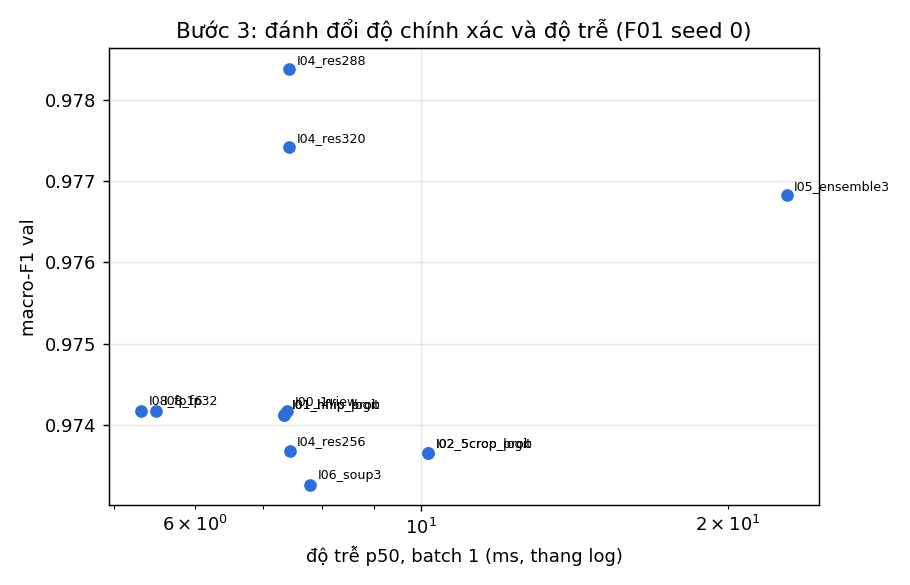

In [25]:
# Ô B3.1 — Bước 3 đã chạy trên Kaggle (code/kaggle_buoc3.ipynb, gọi buoc3.run_buoc3) và gộp bằng Ô B2.M.
#          Ô này chỉ đọc lại kết quả, không tính lại.
import json
from IPython.display import Image, display
pd.set_option("display.width", 250)
inf_val = pd.read_csv(f"{SUB_DIR}/logs/inference_val.csv")
lat = pd.read_csv(f"{SUB_DIR}/logs/latency.csv")
cols = ["method", "views", "aggregate", "input_size", "val_macro_f1", "val_macro_f1_mean_3seed", "val_macro_f1_std_3seed",
        "val_top1", "val_ece", "lat_b1_p50_ms", "lat_b1_p95_ms", "lat_b1_p99_ms", "cost_vs_I00"]
print(inf_val[cols].round(4).to_string(index=False))
print(lat[["label", "gpu", "dtype", "batch", "img_size", "fused_bn", "p50", "p95", "p99", "images_per_s"]].round(2).to_string(index=False))
print("Gộp BN:", json.load(open(f"{SUB_DIR}/logs/bn_fusion_check.json")))
print("Chốt cho chung kết:", json.load(open(f"{SUB_DIR}/logs/buoc3_choice.json")))
display(Image(f"{SUB_DIR}/curves/buoc3_tradeoff.png"))

## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [26]:
# Ô B4.1 — Bước 4 đã chạy trên Kaggle (code/kaggle_buoc4.ipynb, gọi buoc4.run_test): test ĐÚNG MỘT LẦN mỗi seed.
#          KHÔNG gọi lại buoc4.run_test ở đây (hàm tự dừng nếu đã có *_test.csv).
info4 = json.load(open(f"{SUB_DIR}/logs/buoc4_test_info.json"))
print("Phương pháp:", info4["choice"]["method"], "+ TS | T khớp trên val mỗi seed:", info4["temperature"])
print(sorted(os.listdir(f"{SUB_DIR}/predictions")))


Phương pháp: I04_res288 + TS | T khớp trên val mỗi seed: {'seed0': 1.2841365045605444, 'seed1': 1.2164379590021874, 'seed2': 1.2445838228357982}
['.gitkeep', 'F01_seed0_test.csv', 'F01_seed0_val.csv', 'F01_seed1_test.csv', 'F01_seed1_val.csv', 'F01_seed2_test.csv', 'F01_seed2_val.csv', 'F01_uncal_seed0_test.csv', 'F01_uncal_seed1_test.csv', 'F01_uncal_seed2_test.csv', 'T00_seed0_test.csv', 'T00_seed1_test.csv', 'T00_seed2_test.csv']


In [27]:
# Ô B4.2 — chấm lại từ file dự đoán trên Drive bằng eval.py (chỉ đọc CSV, không chạy model)
import subprocess
def eval_py(*args):
    r = subprocess.run([sys.executable, f"{REPO_DIR}/eval.py", *args], capture_output=True, text=True)
    print(r.stdout + r.stderr)
P = f"{SUB_DIR}/predictions"
REF = ["--test-csv", f"{LABELS_DIR}/test_subset0.csv", "--labels", f"{LABELS_DIR}/labels.csv"]
for tag in ("F01", "F01_uncal", "T00"):
    eval_py("score", "--pred", f"{P}/{tag}_seed*_test.csv", *REF, "--tag", tag, "--out", f"{SUB_DIR}/logs/eval")

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9829 ± 0.0010 |
| macro-F1 | 0.9789 ± 0.0012 |
| balanced accuracy | 0.9738 ± 0.0018 |
| ECE (15 bin) | 0.0047 ± 0.0020 |
| NLL | 0.0556 ± 0.0010 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.975 ± 0.007 | 0.968 ± 0.007 | 0.971 ± 0.002 | 226 |
| Lantana | 0.997 ± 0.003 | 0.970 ± 0.005 | 0.983 ± 0.004 | 213 |
| Parkinsonia | 0.976 ± 0.005 | 0.994 ± 0.003 | 0.985 ± 0.001 | 207 |
| Parthenium | 1.000 ± 0.000 | 0.967 ± 0.003 | 0.983 ± 0.001 | 205 |
| Prickly acacia | 0.968 ± 0.005 | 0.958 ± 0.012 | 0.963 ± 0.006 | 213 |
| Rubber vine | 0.992 ± 0.008 | 0.979 ± 0.003 | 0.985 ± 0.005 | 202 |
| Siam weed | 0.994 ± 0.003 | 0.989 ± 0.003 | 0.991 ± 0.003 | 215 |
| Snake weed | 0.975 ± 0.008 | 0.946 ± 0.010 | 0.960 ± 0.003 | 204 |
| Negative | 0.982 ± 0.002 | 0.994 ± 0.000 | 0.988 ± 0.001 | 1822 |

Đã lưu kết quả vào /content/drive/MyDrive/K4-DAY02-PhamVanHoangAnhT

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 98.29% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 4 | 5 | final 0.9789, mốc 0.9709, Δ=+0.0080, s=0.0012 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 96.8% (mốc 88.5%), Snake Weed 94.6% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 1 | 1 | trước 0.0081, sau 0.0047 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9785, test 0.9789, chênh 0.0004 |
| I5 | Cấu hình thời gian thực | 2 | 2 | p95 = 7.9 ms (ngân sách 100 ms), đo đúng cách |

**Tổng các ý đã chấm: 19 / 20** (phần I tối đa 20).

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).



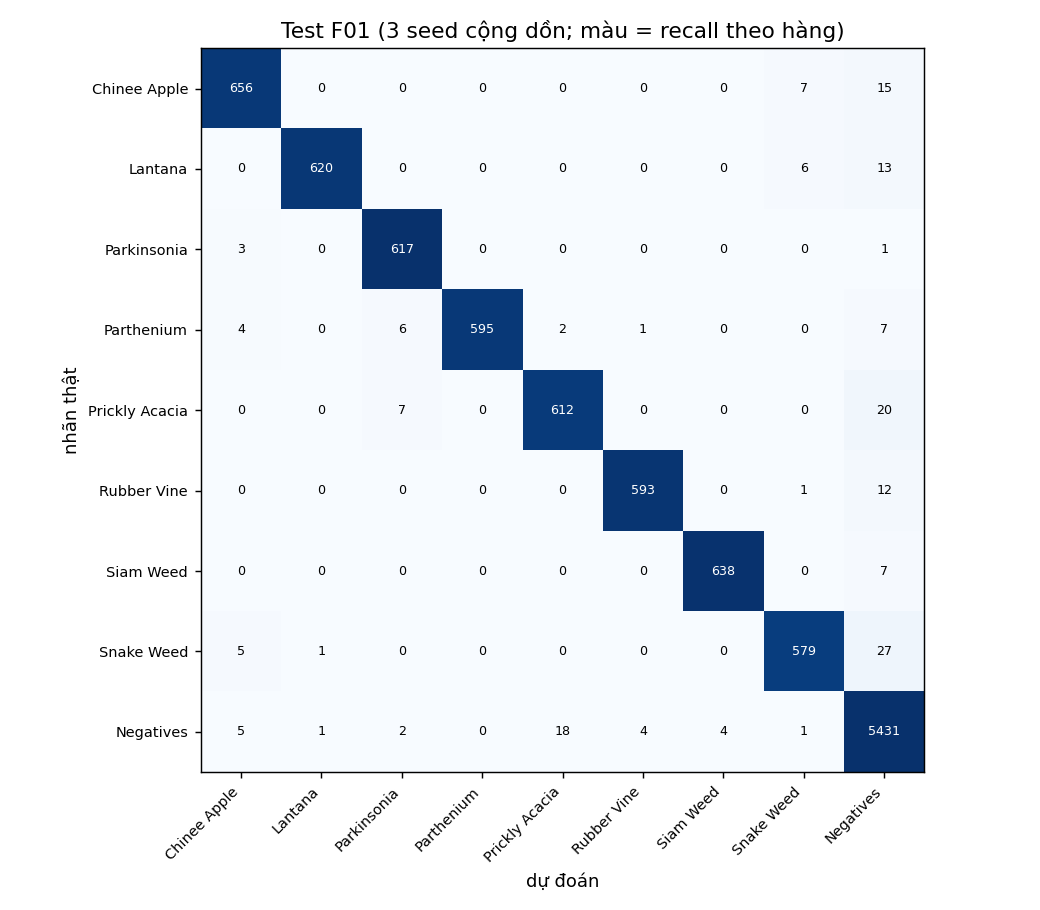

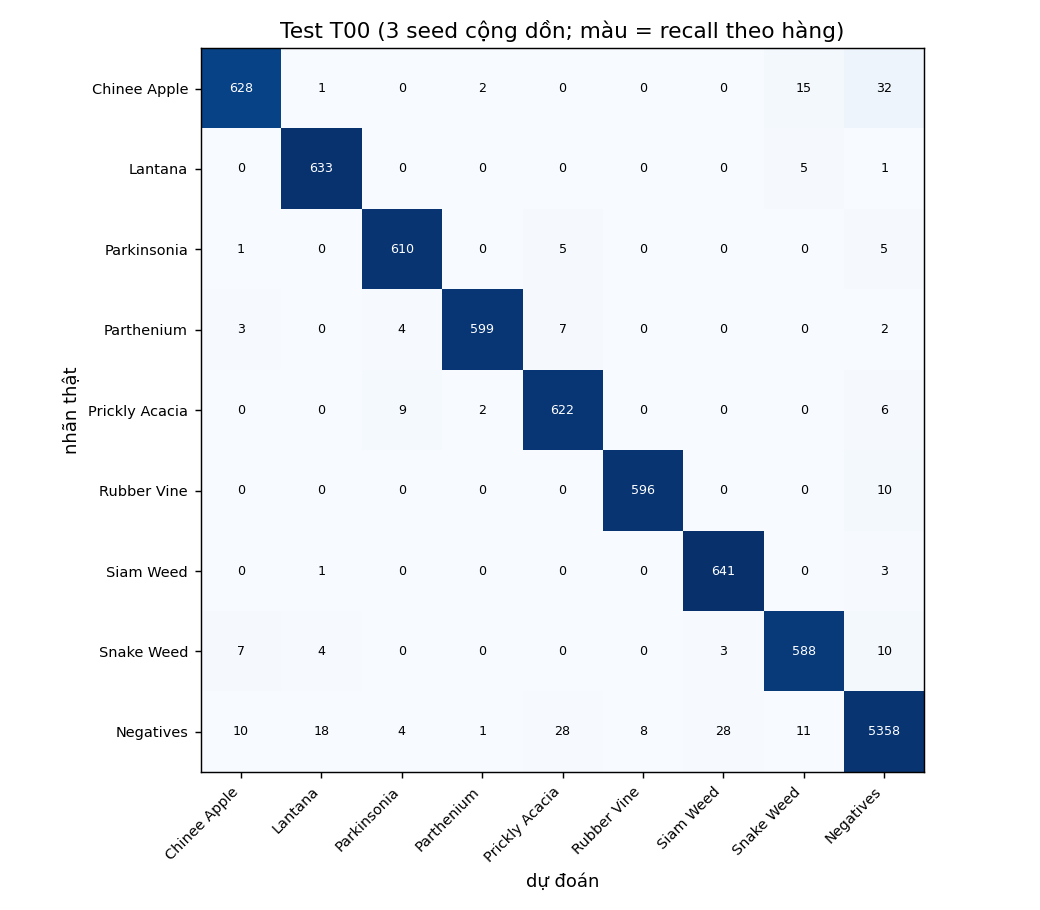

In [28]:
# Ô B4.3 — tự chấm phần I (I1-I5). p95 batch 1 của cấu hình chung kết lấy từ Bước 3 (latency.csv, dòng I04_res288).
p95_rt = info4["choice"]["realtime_p95_b1_ms"]
eval_py("grade", "--final", f"{P}/F01_seed*_test.csv", "--baseline", f"{P}/T00_seed*_test.csv",
        "--uncal", f"{P}/F01_uncal_seed*_test.csv", "--final-val", f"{P}/F01_seed*_val.csv",
        "--latency-p95-ms", f"{p95_rt:.2f}", "--latency-method", "proper", *REF,
        "--val-csv", f"{LABELS_DIR}/val_subset0.csv", "--out", f"{SUB_DIR}/logs/eval")
for exp in ("F01", "T00"):
    display(Image(f"{SUB_DIR}/curves/confusion_test_{exp}.png", width=520))

## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

Đã ghi /content/drive/MyDrive/K4-DAY02-PhamVanHoangAnhTu-2A202602507/submissions/2A202602507_pham_van_hoang_anh_tu/results.xlsx | {'Summary': (12, 11), 'Backbones': (6, 14), 'Training': (14, 14), 'Inference': (13, 19), 'Final': (8, 10), 'PerClass': (18, 9), 'Latency': (15, 14)}


,hạng,exp_id,sheet,mô tả,macro-F1 val,macro-F1 test,top-1 test,ECE test,p95 b1 (ms),chi phí so với I00 (p95),ghi chú
0,CHUNG KẾT,F01,Final,ConvNeXt-T + TrivialAugment + res288 + TS,0.9785 ± 0.0008,0.9789 ± 0.0012,0.9829 ± 0.0010,0.0047 ± 0.0020,7.890177,1.001645,mean ± std 3 seed
1,MỐC,T00 + I00 (mốc),Final,ConvNeXt-T + T00 + I00,0.9688 ± 0.0046,0.9709 ± 0.0012,0.9766 ± 0.0016,0.0099 ± 0.0006,7.877218,1.000000,mean ± std 3 seed
2,1,I04_res288,Inference,F01 + res288,0.978476,NaN,NaN,NaN,7.890177,1.001645,mean 3 seed
3,2,I05_ensemble3,Inference,F01 + ensemble3,0.976825,NaN,NaN,NaN,25.351795,3.218369,3 checkpoint F01 seed 0-2
4,3,I04_res320,Inference,F01 + res320,0.976729,NaN,NaN,NaN,8.984874,1.140615,mean 3 seed
5,4,I04_res256,Inference,F01 + res256,0.975285,NaN,NaN,NaN,8.100661,1.028366,mean 3 seed
6,5,I02_5crop_prob,Inference,F01 + 5crop_prob,0.975157,NaN,NaN,NaN,12.221546,1.551505,mean 3 seed
7,6,I02_5crop_logit,Inference,F01 + 5crop_logit,0.974983,NaN,NaN,NaN,12.221546,1.551505,mean 3 seed
8,7,I01_hflip_logit,Inference,F01 + hflip_logit,0.974624,NaN,NaN,NaN,8.977288,1.139652,mean 3 seed
9,8,I00_1view,Inference,F01 + 1view,0.974588,NaN,NaN,NaN,7.877218,1.000000,mean 3 seed


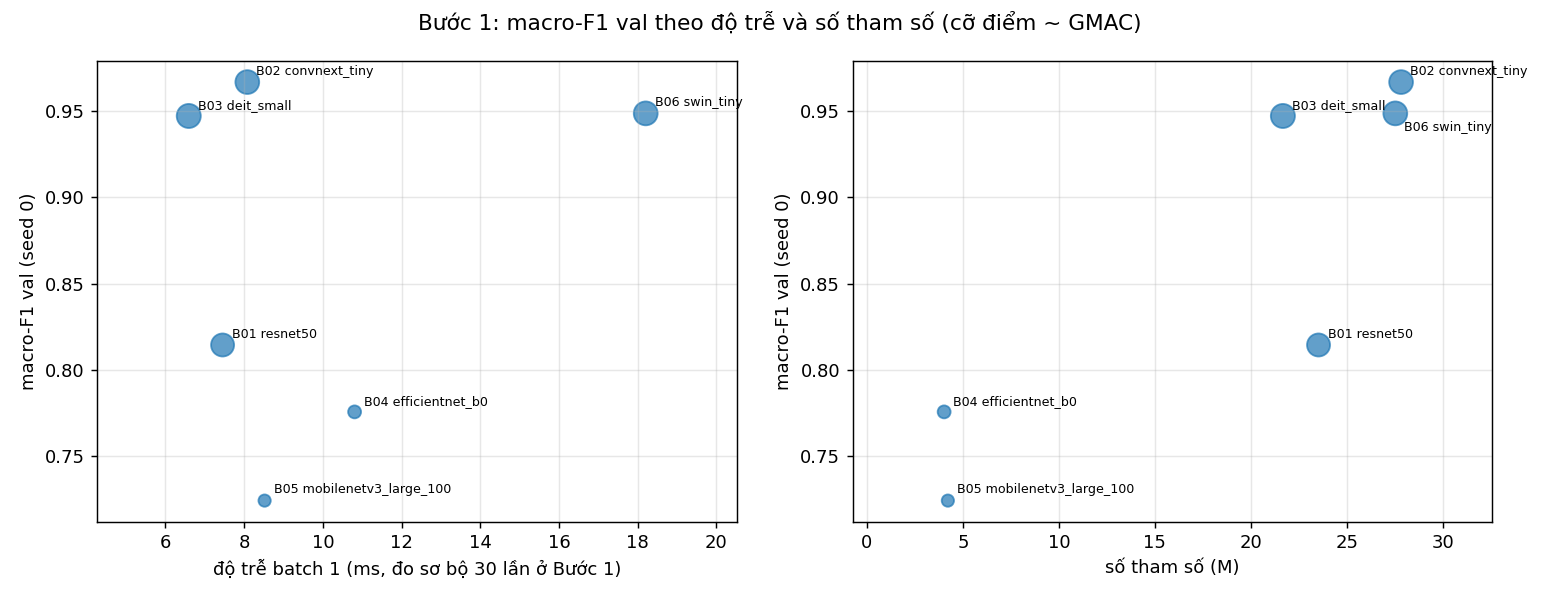

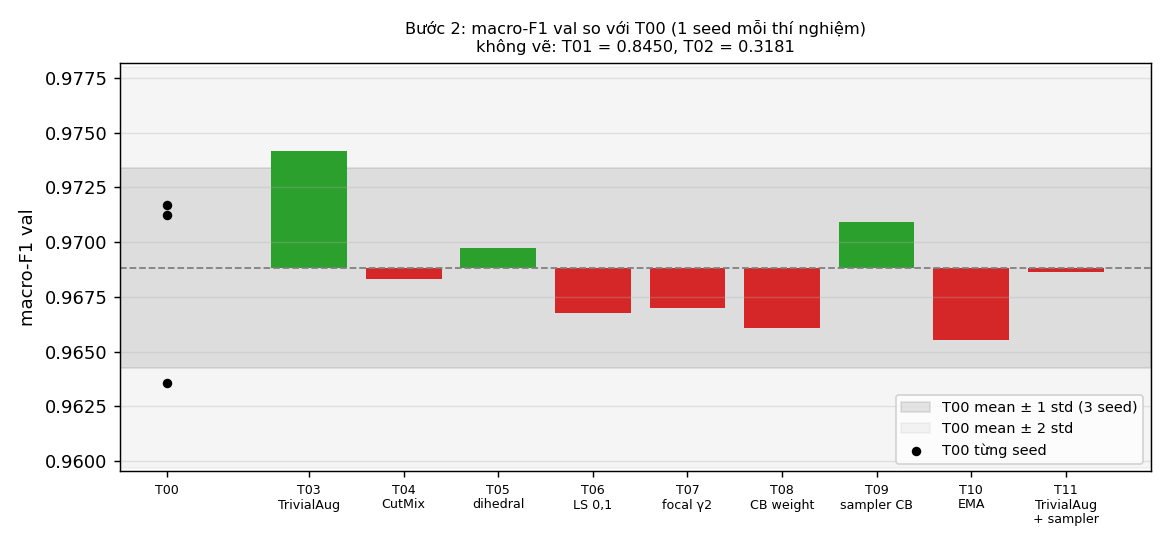

In [29]:
# Ô B5.1 — results.xlsx (7 sheet, GUIDE mục 6.1) gom thẳng từ log thật + 2 biểu đồ tổng hợp cho báo cáo
import buoc5
importlib.reload(buoc5)
sheets = buoc5.build_results(RUNS_DIR, SUB_DIR)
buoc5.plot_backbones(sheets["Backbones"], f"{SUB_DIR}/curves/summary_backbones.png")
buoc5.plot_ablation(sheets["Training"], f"{SUB_DIR}/curves/summary_training.png")
print("Đã ghi", f"{SUB_DIR}/results.xlsx", "|", {k: v.shape for k, v in sheets.items()})
display(sheets["Summary"])
display(Image(f"{SUB_DIR}/curves/summary_backbones.png", width=800))
display(Image(f"{SUB_DIR}/curves/summary_training.png", width=800))

 số ảnh (3 seed)      nhãn thật        dự đoán
              27     Snake Weed      Negatives
              20 Prickly Acacia      Negatives
              18      Negatives Prickly Acacia
              15   Chinee Apple      Negatives
              13        Lantana      Negatives
              12    Rubber Vine      Negatives
Số ảnh mỗi cặp (seed 0): {(0, 7): 1, (7, 0): 2, (7, 8): 11, (0, 8): 5}


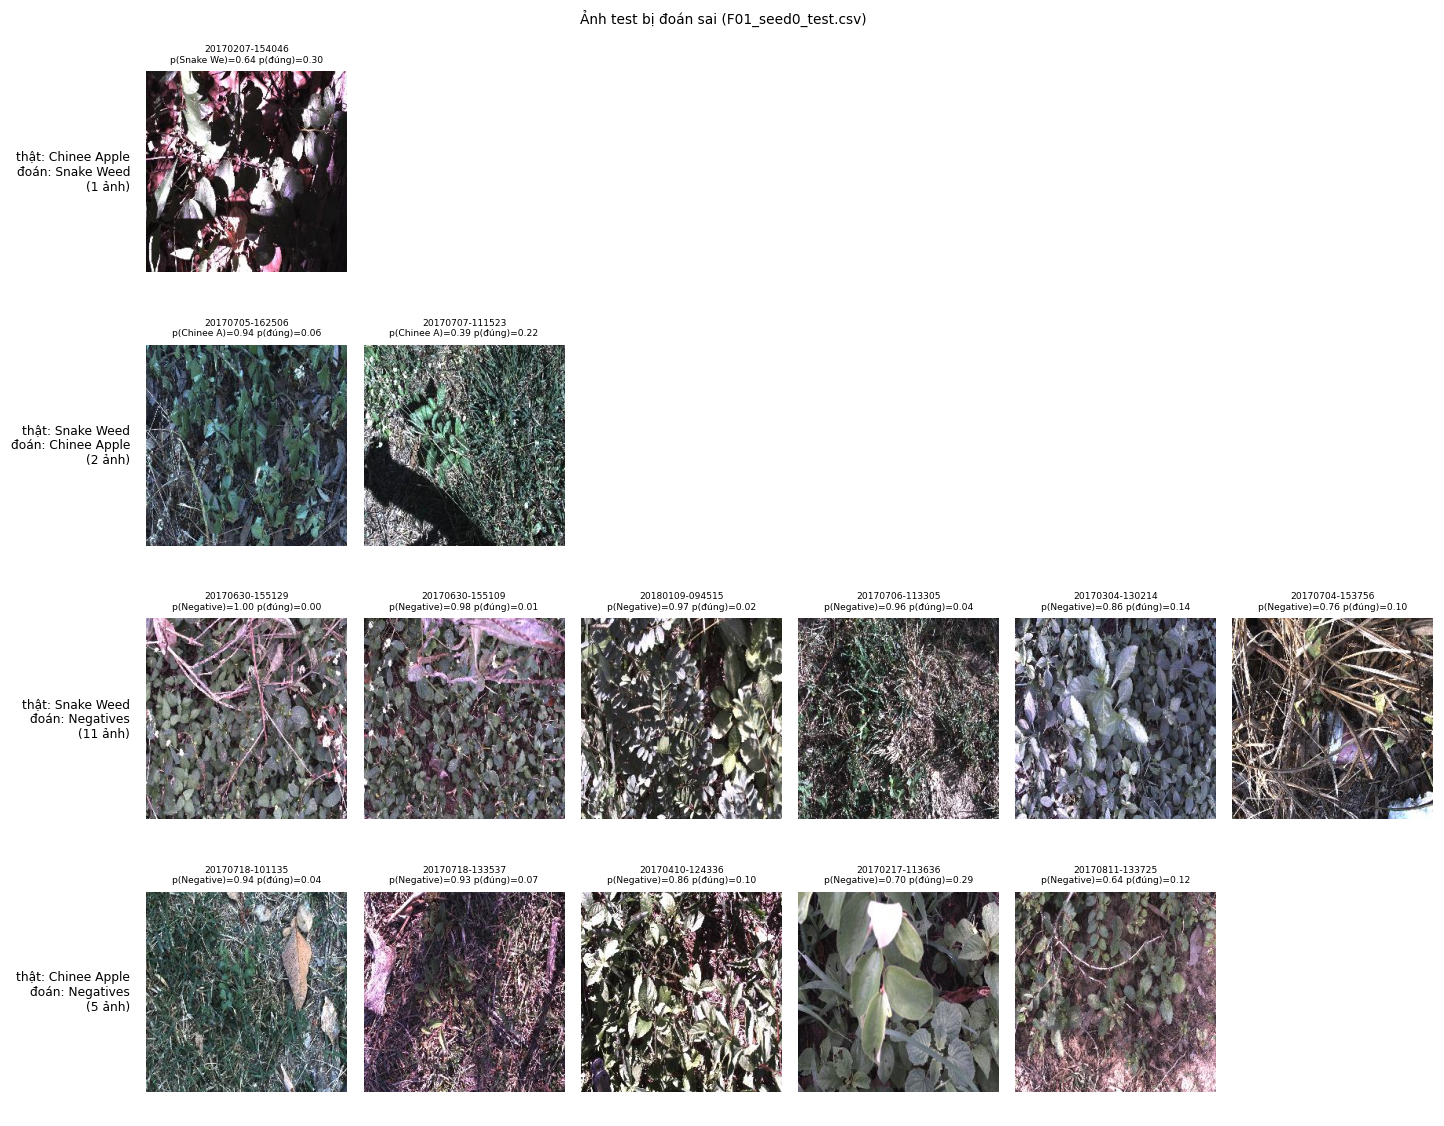

In [30]:

# ==== Ô B5.2 ====
# Ô B5.2 — phân tích lỗi: ảnh test bị đoán sai của F01 seed 0 (Chinee apple <-> Snake weed, và lớp cỏ -> Negative)
print(buoc5.top_confusions(f"{SUB_DIR}/logs/eval/F01_confusion_sum.csv").to_string(index=False))
counts = buoc5.plot_errors(f"{SUB_DIR}/predictions/F01_seed0_test.csv", IMAGES_DIR, f"{SUB_DIR}/curves/errors_F01_seed0.png",
                           pairs=((0, 7), (7, 0), (7, 8), (0, 8)), n=6)
print("Số ảnh mỗi cặp (seed 0):", counts)
display(Image(f"{SUB_DIR}/curves/errors_F01_seed0.png"))


In [31]:

# ==== Ô B5.3 ====
# Ô B5.3 — tự kiểm tra bài nộp trước khi push (rỗng = đạt)
problems = buoc5.check_submission(SUB_DIR)
print("ĐẠT" if not problems else "\n".join(problems))


ĐẠT
